# **Identificação**:

- `Número de aluno`:
- `Nome`:
- `Data`: / /

# **Instruções:**
- Justifique suas respostas quando solicitado.
- Não é permitido a consulta a outros alunos ou a qualquer material externo.
- Eletronic devices estão proibidos durante o teste.
- Teste seus códigos com diferentes entradas para garantir seu funcionamento.
- Salve o notebook com seu `número de aluno` antes de entregar. Exemplo: `2022000000.ipynb`.
- Faça silêncio em respeito aos colegas que ainda estão realizando o teste.

# **Questões:**

## 1. Implemente uma Máquina de Turing:

- Esta máquina deve ser capaz de mover o ponteiro de leitura/escrita para a direita ou para a esquerda, ler o símbolo atual, escrever um novo símbolo e mudar de estado conforme as regras de transição.

In [2]:
class TuringMachine:
    def __init__(self, transition_rules):
        self.state = None
        self.position = 0
        self.tape = []
        self.transition_rules = transition_rules

    def initialize(self, tape, initial_state, position=0):
        self.tape = list(tape)
        self.state = initial_state
        self.position = position

    def run(self, max_steps=1000):
        steps = 0

        while self.state != 'qf' and steps < max_steps:
            self.step()
            steps += 1

    def step(self):

        if self.position < 0:
            self.tape = ['_'] + self.tape
            self.position = 0
        elif self.position >= len(self.tape):
            self.tape.append('_')


        current_symbol = self.tape[self.position]


        key = (self.state, current_symbol)
        if key not in self.transition_rules:
            print(f"No transition rule for state {self.state} and symbol {current_symbol}")
            return False


        next_state, write_symbol, direction = self.transition_rules[key]


        self.tape[self.position] = write_symbol


        self.state = next_state

        if direction == 'R':
            self.position += 1
        elif direction == 'L':
            self.position -= 1

        return True

    def display(self):
        print(f"Tape: {''.join(self.tape)}")
        print(f"State: {self.state}")
        print(f"Position: {self.position}")


        visual = ""
        for i, symbol in enumerate(self.tape):
            if i == self.position:
                visual += f"[{symbol}]"
            else:
                visual += symbol
        print(f"Visual: {visual}")
        print("-------------------")

## 2. Analise as regras da tabela de transições a seguir e forneça a saída conforme a fita abaixo:

O estado `qf` é o **estado final**. A máquina começa no estado `q0` e lê o símbolo atual na `posição 0` da fita.

| Estado atual | Símbolo lido | Novo estado | Símbolo escrito | Direção |
|--------------|--------------|-------------|------------------|----------|
| q0 | 0 | q1 | 0 | R |
| q0 | 1 | q1 | 1 | R |
| q0 | _ | qf | _ | L |
| q1 | 0 | q0 | 0 | R |
| q1 | 1 | q1 | 1 | R |
| q1 | _ | qf | _ | L |

- `Fita`: `10010_0_1__`

A cada iteração, exiba o a fita, o estado atual da máquina e a posição do ponteiro de leitura/escrita.

In [3]:
# sua implementação aqui
tape = ['1', '0', '0', '1', '0', '_', '0', '_', '1', '_', '_']

In [4]:

transition_rules = {
    ('q0', '0'): ('q1', '0', 'R'),
    ('q0', '1'): ('q1', '1', 'R'),
    ('q0', '_'): ('qf', '_', 'L'),
    ('q1', '0'): ('q0', '0', 'R'),
    ('q1', '1'): ('q1', '1', 'R'),
    ('q1', '_'): ('qf', '_', 'L')
}


tm = TuringMachine(transition_rules)
tm.initialize(tape, 'q0', 0)


print("Estado Inicial:")
tm.display()

while tm.state != 'qf':
    if tm.step():
        tm.display()
    else:
        break

Estado Inicial:
Tape: 10010_0_1__
State: q0
Position: 0
Visual: [1]0010_0_1__
-------------------
Tape: 10010_0_1__
State: q1
Position: 1
Visual: 1[0]010_0_1__
-------------------
Tape: 10010_0_1__
State: q0
Position: 2
Visual: 10[0]10_0_1__
-------------------
Tape: 10010_0_1__
State: q1
Position: 3
Visual: 100[1]0_0_1__
-------------------
Tape: 10010_0_1__
State: q1
Position: 4
Visual: 1001[0]_0_1__
-------------------
Tape: 10010_0_1__
State: q0
Position: 5
Visual: 10010[_]0_1__
-------------------
Tape: 10010_0_1__
State: qf
Position: 4
Visual: 1001[0]_0_1__
-------------------


O estado `qf` é o **estado final**. A máquina começa no estado `q1` e lê o símbolo atual na `posição 2` da fita (`ponteiro no símbolo 'A'`).

| Estado atual | Símbolo lido | Novo estado | Símbolo escrito | Direção |
|--------------|--------------|-------------|------------------|----------|
| q0 | 0 | q1 | 1 | R |
| q0 | 1 | q1 | 0 | R |
| q0 | _ | qf | _ | L |
| q0 | A | q0 | _ | R |
| q1 | 0 | q0 | 1 | R |
| q1 | 1 | q1 | 0 | R |
| q1 | _ | qf | _ | L |
| q1 | A | q0 | _ | R |


- `Fita`: `1AA10A_0A_1__11`

A cada iteração, exiba o a fita, o estado atual da máquina e a posição do ponteiro de leitura/escrita.

In [5]:
# sua implementação aqui
tape = ['1', 'A', 'A', '1', '0', 'A', '_', '0', 'A', '_', '1', '_', '_', '1', '1']

In [6]:

transition_rules_2 = {
    ('q0', '0'): ('q1', '1', 'R'),
    ('q0', '1'): ('q1', '0', 'R'),
    ('q0', '_'): ('qf', '_', 'L'),
    ('q0', 'A'): ('q0', '_', 'R'),
    ('q1', '0'): ('q0', '1', 'R'),
    ('q1', '1'): ('q1', '0', 'R'),
    ('q1', '_'): ('qf', '_', 'L'),
    ('q1', 'A'): ('q0', '_', 'R')
}


tm2 = TuringMachine(transition_rules_2)
tm2.initialize(tape, 'q1', 2)


print("Estado Inicial:")
tm2.display()

while tm2.state != 'qf':
    if tm2.step():
        tm2.display()
    else:
        break



Estado Inicial:
Tape: 1AA10A_0A_1__11
State: q1
Position: 2
Visual: 1A[A]10A_0A_1__11
-------------------
Tape: 1A_10A_0A_1__11
State: q0
Position: 3
Visual: 1A_[1]0A_0A_1__11
-------------------
Tape: 1A_00A_0A_1__11
State: q1
Position: 4
Visual: 1A_0[0]A_0A_1__11
-------------------
Tape: 1A_01A_0A_1__11
State: q0
Position: 5
Visual: 1A_01[A]_0A_1__11
-------------------
Tape: 1A_01__0A_1__11
State: q0
Position: 6
Visual: 1A_01_[_]0A_1__11
-------------------
Tape: 1A_01__0A_1__11
State: qf
Position: 5
Visual: 1A_01[_]_0A_1__11
-------------------


## 3. A máquina de Turing é um modelo abstrato de tamanho de fita infinito. O que você fez para modelar isso? Em outras palavras, assumindo que o ponteiro chegou no último símbolo da fita e recebeu instrução para movimentar-se para a direita, o que acontece?

In [9]:
The infinite tape is modeled with lists or dictionaries.
When moving to the right of the last symbol, a new blank cell is added.

## 4. Construção de Neurônio:
- Implemente um neurônio `McCulloch-Pitts` com dois pesos `1` e limiar `2`.

Esse neurônio simula qual porta lógica?
- a) OR
- b) AND
- c) NOT
- d) NAND

Explique sua resposta e mostre a tabela verdade resultante.

Entradas | Saída
---------|------
  0, 0  |  0
  0, 1  |  0
  1, 0  |  0
  1, 1  |  1


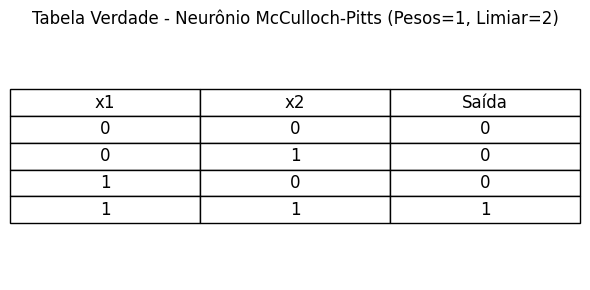

In [8]:
def mcculloch_pitts_neuron(x1, x2, weights=[1, 1], threshold=2):

    weighted_sum = x1 * weights[0] + x2 * weights[1]

    if weighted_sum >= threshold:
        return 1
    else:
        return 0

print("Entradas | Saída")
print("---------|------")
for x1 in [0, 1]:
    for x2 in [0, 1]:
        output = mcculloch_pitts_neuron(x1, x2)
        print(f"  {x1}, {x2}  |  {output}")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.table import Table


inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
outputs = [mcculloch_pitts_neuron(x1, x2) for x1, x2 in inputs]


fig, ax = plt.subplots(figsize=(6, 3))
ax.set_axis_off()

table_data = [['x1', 'x2', 'Saída']]
for (x1, x2), output in zip(inputs, outputs):
    table_data.append([x1, x2, output])

table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

plt.title("Tabela Verdade - Neurônio McCulloch-Pitts (Pesos=1, Limiar=2)")
plt.tight_layout()
plt.show()

## 5. Portas Lógicas:
Implemente neurônios que simulem:
- Porta AND para dois neurônios
- Porta AND para três neurônios

O output deve considerar a exibição da tabela verdade para cada porta lógica. Utilize pesos e limiares adequados para cada porta lógica.

Porta AND - 2 Entradas:
x1 | x2 | Saída
---+----+------
 0 |  0 |   0
 0 |  1 |   0
 1 |  0 |   0
 1 |  1 |   1


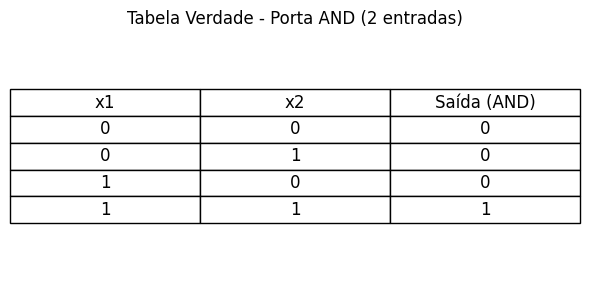

In [11]:
def mcculloch_pitts_neuron(inputs, weights, threshold):

    if len(inputs) != len(weights):
        raise ValueError("Número de entradas e pesos deve ser igual")


    weighted_sum = sum(x * w for x, w in zip(inputs, weights))


    if weighted_sum >= threshold:
        return 1
    else:
        return 0


def AND_2inputs(x1, x2):
    weights = [1, 1]
    threshold = 2
    return mcculloch_pitts_neuron([x1, x2], weights, threshold)


print("Porta AND - 2 Entradas:")
print("x1 | x2 | Saída")
print("---+----+------")
for x1 in [0, 1]:
    for x2 in [0, 1]:
        output = AND_2inputs(x1, x2)
        print(f" {x1} |  {x2} |   {output}")


import numpy as np
import matplotlib.pyplot as plt


inputs_2 = [(0, 0), (0, 1), (1, 0), (1, 1)]
outputs_2 = [AND_2inputs(x1, x2) for x1, x2 in inputs_2]


fig, ax = plt.subplots(figsize=(6, 3))
ax.set_axis_off()

table_data = [['x1', 'x2', 'Saída (AND)'] ]
for (x1, x2), output in zip(inputs_2, outputs_2):
    table_data.append([x1, x2, output])

table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

plt.title("Tabela Verdade - Porta AND (2 entradas)")
plt.tight_layout()
plt.show()

## 6. Signal Gate com dois destinos
Implemente dois neurônios para simular um sistema onde:
- `Receiver 1` ativa se `entrada = 1` e `controle = 0`
- `Receiver 2` ativa se `entrada = 1` e `controle = 1`

Defina os pesos e limiares para cada neurônio.

Lógica com Neurônios:
- Receiver 1 (entrada = 1, controle = 0)
Usamos pesos [1, 1]

    - Entrada = 1, Controle = 0 → [1, 1] com valores [1, 1 - controle]

    - Limiar = 2

    - Só ativa se entrada=1 e controle=0

- Receiver 2 (entrada = 1, controle = 1)
    - Entrada = 1, Controle = 1 → [1, 1]

    - Limiar = 2

    - Só ativa se entrada=1 e controle=1

Signal Gate com Dois Destinos
Entrada | Controle | Receiver 1 | Receiver 2
--------|----------|------------|----------
   0    |    0     |     0      |     0
   0    |    1     |     0      |     0
   1    |    0     |     1      |     0
   1    |    1     |     0      |     1


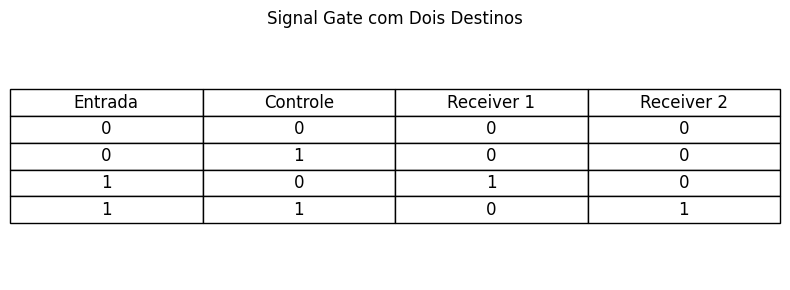

In [12]:
def receiver_1(entrada, controle):

    controle_invertido = 1 - controle


    weights = [1, 1]


    threshold = 2

    return mcculloch_pitts_neuron([entrada, controle_invertido], weights, threshold)

def receiver_2(entrada, controle):

    weights = [1, 1]


    threshold = 2

    return mcculloch_pitts_neuron([entrada, controle], weights, threshold)


print("Signal Gate com Dois Destinos")
print("Entrada | Controle | Receiver 1 | Receiver 2")
print("--------|----------|------------|----------")
for entrada in [0, 1]:
    for controle in [0, 1]:
        r1 = receiver_1(entrada, controle)
        r2 = receiver_2(entrada, controle)
        print(f"   {entrada}    |    {controle}     |     {r1}      |     {r2}")


import numpy as np
import matplotlib.pyplot as plt


inputs_sg = [(x1, x2) for x1 in [0, 1] for x2 in [0, 1]]
outputs_r1 = [receiver_1(x1, x2) for x1, x2 in inputs_sg]
outputs_r2 = [receiver_2(x1, x2) for x1, x2 in inputs_sg]


fig, ax = plt.subplots(figsize=(8, 3))
ax.set_axis_off()

table_data = [['Entrada', 'Controle', 'Receiver 1', 'Receiver 2']]
for (x1, x2), r1, r2 in zip(inputs_sg, outputs_r1, outputs_r2):
    table_data.append([x1, x2, r1, r2])

table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

plt.title("Signal Gate com Dois Destinos")
plt.tight_layout()
plt.show()



## 7. Considerando a rede neural abaixo:

![image.png](attachment:image.png)

- 7.1. qual o output em cada instante de tempo para a entrada a seguir:

    - 10101110001110000010



In [13]:
def neuronio_limiar_1(entrada):

    return 1 if entrada >= 1 else 0

def neuronio_limiar_2(entrada):

    return 1 if entrada >= 2 else 0

def processamento_rede_neural(sequencia_entrada):


    if isinstance(sequencia_entrada, str):
        entrada = [int(bit) for bit in sequencia_entrada]
    else:
        entrada = sequencia_entrada


    buffer_neuronio_meio = 0


    saida = []


    print("Processamento da Rede Neural:")
    print("t | Entrada | Buffer | Saída")
    print("--+---------|--------|-------")

    for t, bit in enumerate(entrada):

        buffer_neuronio_meio = neuronio_limiar_1(bit + buffer_neuronio_meio)


        output = neuronio_limiar_2(bit + buffer_neuronio_meio)


        saida.append(output)


        print(f"{t:2d}|    {bit}    |   {buffer_neuronio_meio}    |   {output}")

    return saida


entrada = "10101110001110000010"
resultado = processamento_rede_neural(entrada)

print("\nResultado final:")
print(f"Entrada: {entrada}")
print(f"Saída:   {''.join(map(str, resultado))}")

Processamento da Rede Neural:
t | Entrada | Buffer | Saída
--+---------|--------|-------
 0|    1    |   1    |   1
 1|    0    |   1    |   0
 2|    1    |   1    |   1
 3|    0    |   1    |   0
 4|    1    |   1    |   1
 5|    1    |   1    |   1
 6|    1    |   1    |   1
 7|    0    |   1    |   0
 8|    0    |   1    |   0
 9|    0    |   1    |   0
10|    1    |   1    |   1
11|    1    |   1    |   1
12|    1    |   1    |   1
13|    0    |   1    |   0
14|    0    |   1    |   0
15|    0    |   1    |   0
16|    0    |   1    |   0
17|    0    |   1    |   0
18|    1    |   1    |   1
19|    0    |   1    |   0

Resultado final:
Entrada: 10101110001110000010
Saída:   10101110001110000010


- 7.2 Explique o funcionamento da rede neural

## 8. O artigo trabalhado em aula, "LLMs and Artificial General Intelligence (AGI)" apresenta entre vários outros pontos a definição de AGI segundo a OpenAI. Por que desafiar tal conceito? Comente sobre a definição de AGI e como ela se relaciona com o conceito de inteligência geral humana. Você concorda com a definição apresentada? Justifique sua resposta.

In [14]:
i think because the AGI is very narrow and just do the tasks with out that ,
I disagree with the definition as it misses the flexibility and transparency essential to intelligence.

SyntaxError: invalid syntax (<ipython-input-14-e68da28a0ce4>, line 1)